In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# Explicacion

Este caso se intentó hacer antes de evaluar los contenidos de la clase 5. La logica que se buscó fue:

1. Reescalar la imagen del logo para que siempre sea mas pequeña que la imagen a detectar
2. Utilizar canny, para quitar influencia de colores, fondos, etc, del logo
3. De forma iterativa, ir intentando detectar elementos en la imagen, hasta que la imagen a detectar sea del tamaño del logo

Esto unicamente nos funcionó en un caso, pero lo dejamos como muestra de la logica que intentamos aplicar

In [2]:
img_path = "images/coca_logo_1.png"

template_path = "template/pattern.png"

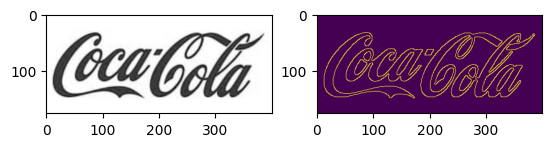

In [3]:
# Procesamos template

template_img = cv.imread(template_path,0)
template_edges = cv.Canny(template_img,100,200)


plt.figure()
plt.subplot(1,2,1)
plt.imshow(template_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(template_edges)
plt.show()


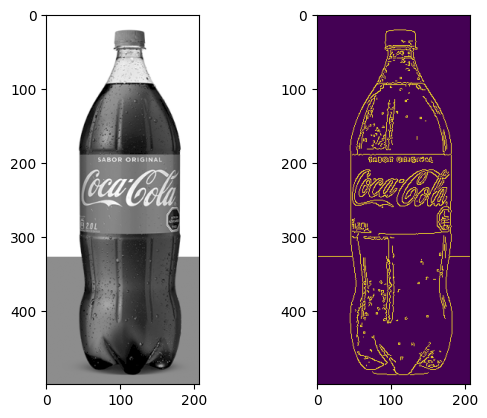

In [4]:
img_grayscale = cv.imread(img_path,0)
image_edges = cv.Canny(img_grayscale,100,200)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(img_grayscale, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(image_edges)
plt.show()

In [11]:
resize_percentaje = 40

In [20]:
max_dim = np.argmax(template_edges.shape)

scale_factor = ((img_grayscale.shape[max_dim]*resize_percentaje/100)/template_edges.shape[max_dim])

# Resize the image (scaling down)
resized_down_template = cv.resize(template_edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)


#edges = cv.Canny(resized_down_template,100,200)
 


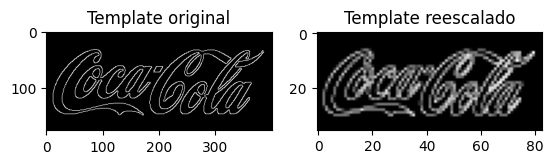

In [21]:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(template_edges, cmap='gray')
plt.title("Template original")
plt.subplot(1,2,2)
plt.imshow(resized_down_template, cmap= 'gray')
plt.title("Template reescalado")
plt.show()

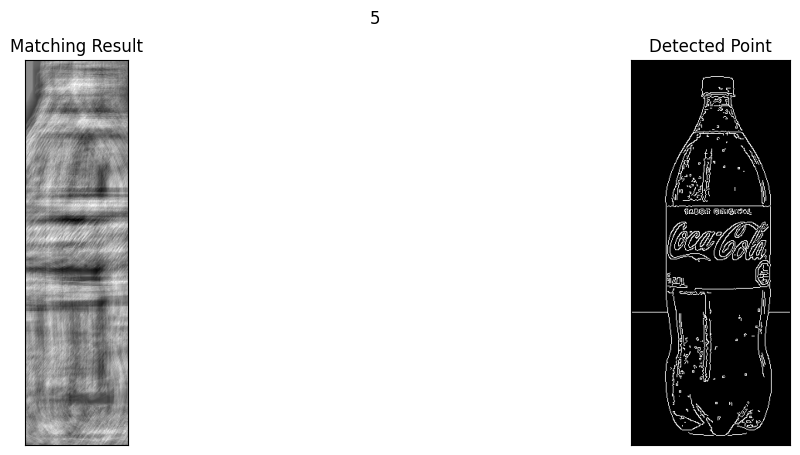

(500, 207)


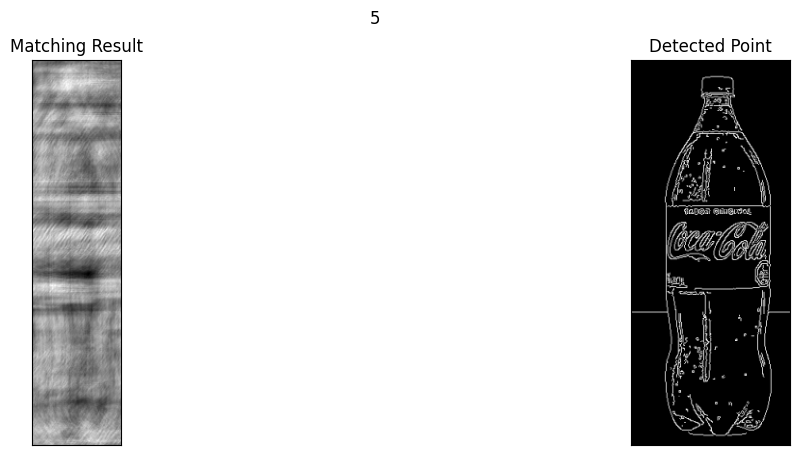

(400, 166)


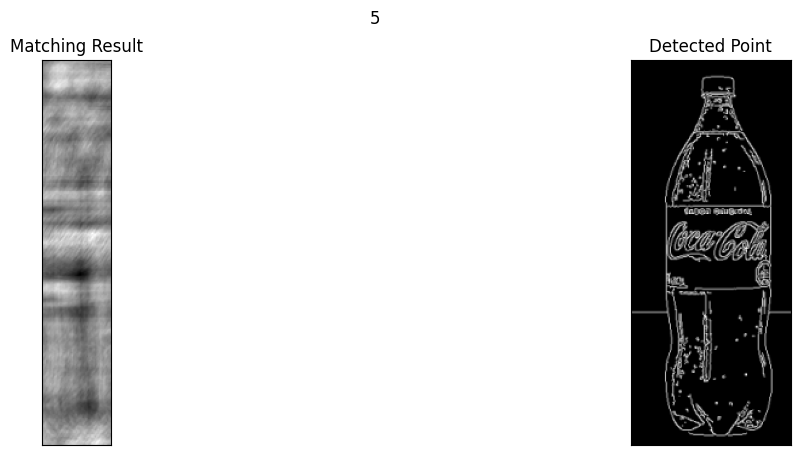

(320, 133)
Valor de confianza de deteccion: 0.510247528553009


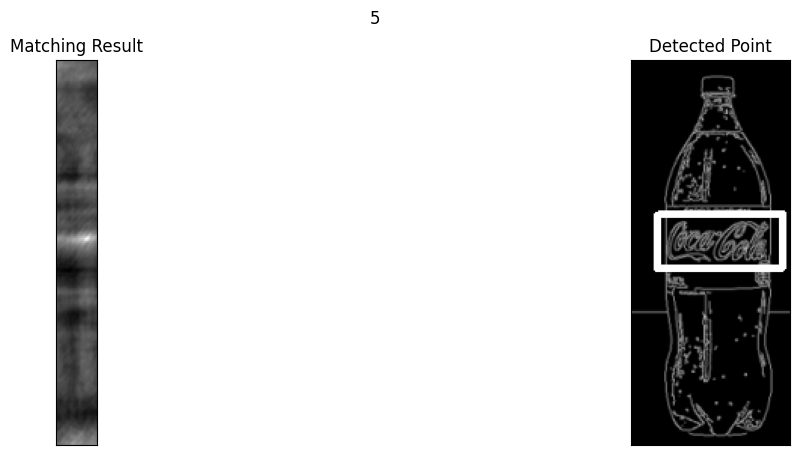

(256, 106)


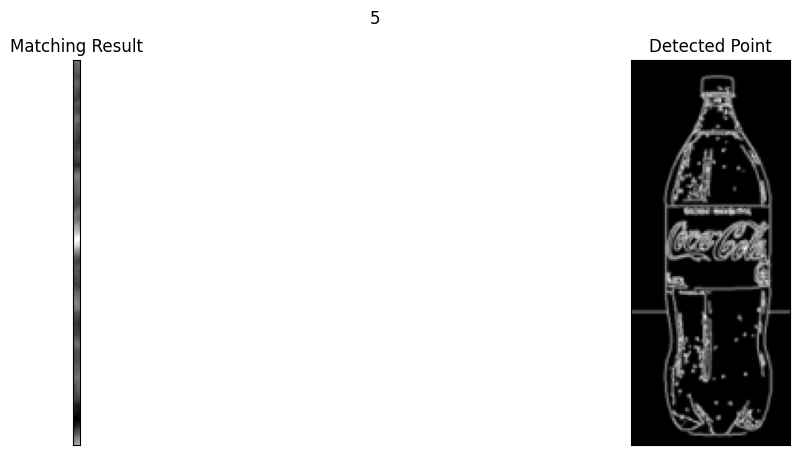

(205, 85)


In [38]:
current_image = image_edges.copy()

edges = resized_down_template.copy()

while (current_image.shape[0] > edges.shape[0]) and (current_image.shape[1] > edges.shape[1]):

    img_show = current_image.copy()

    method = eval('cv.TM_CCOEFF_NORMED')


    #current_edges = cv.Canny(current_image,100,200)

    res = cv.matchTemplate(current_image, edges, method)

    # Encontramos los valores máximos y mínimos
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    w, h = edges.shape[::-1]

    threshold = 0.4

    loc = np.where( res >= threshold)
    for pt in zip(*loc[::-1]):
        cv.rectangle(img_show, pt, (pt[0] + w, pt[1] + h), (255,255,255), 2)

    if np.max(res) > threshold:
        print(f"Valor de confianza de deteccion: {np.max(res)}")

    # Graficamos el procesamiento y la salida
    #----------------------------------------
    plt.figure(figsize=(15, 5))
    # Resultado de coincidencia
    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

    # Imagen original con recuadros
    plt.subplot(122),plt.imshow(img_show, cmap='gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

    #plt.subplot(133),plt.imshow(current_edges,cmap='grey')
    #plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

    plt.suptitle(method)
    plt.show()
    
    print(current_image.shape)
    current_image = cv.resize(current_image, None, fx=0.80, fy=0.80, interpolation=cv.INTER_AREA).copy()
    #cv.imshow('Downscaled', current_image)
    #cv.waitKey(500)

Esto parece indicar resultados correctos, pero existe un problema. Si analizamos el valor de confianza encontramos que este es del 51%, no es muy alto. Si lo verificamos para otra imagen, tenemos: